# Graph Mining
## Lab 4: Hierarchical Clustering

In this lab, you will learn to analyse the hierarchical structure of a graph.

### André Santos Rocha

## Import

In [1]:
from IPython.display import SVG

In [2]:
import numpy as np
from scipy import sparse

In [3]:
from sknetwork.data import load_netset, karate_club
from sknetwork.hierarchy import LouvainIteration, Paris, cut_straight
from sknetwork.ranking import PageRank
from sknetwork.visualization import visualize_graph, visualize_dendrogram
from sknetwork.utils import get_membership
from sknetwork.linalg import normalize
from sknetwork.clustering import get_modularity, aggregate_graph

## Data

We will work on the following graphs (see the [NetSet](https://netset.telecom-paristech.fr/) collection for details):
* Openflights (graph)
* WikiVitals (directed graph)

In [4]:
openflights = load_netset('openflights')
wikivitals = load_netset('wikivitals')

Parsing files...
Done.
Parsing files...
Done.


## 1. Graphs

## Karate Club


We first consider the [karate club graph](https://en.wikipedia.org/wiki/Zachary%27s_karate_club), a small graph with ground-truth clusters.

In [5]:
dataset = karate_club(True)

In [6]:
adjacency = dataset.adjacency
position = dataset.position
labels_true = dataset.labels

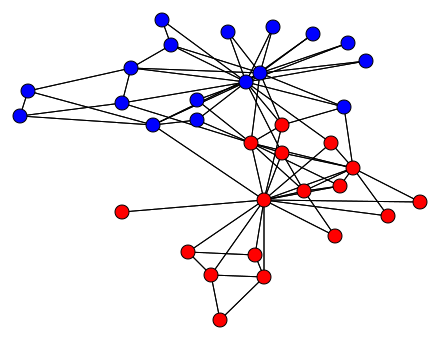

In [7]:
image = visualize_graph(adjacency, position, labels=labels_true)
SVG(image)

## To do

* Cluster the graph by the hierarchical Louvain algorithm (divisive algorithm, top-down).
* Display the dendrogram.
* How many clusters are there at depth 1?
* Display the graph with the corresponding clustering.
* How many clusters are there at depth 2?

#### **Answers**

- There are 4 clusters at depth 1.

- There are 9 clusters at depth 2.

In [8]:
louvain = LouvainIteration()

In [9]:
dendrogram = louvain.fit_predict(adjacency)

In [10]:
print(dendrogram)

[[ 9.  7.  1.  2.]
 [13. 12.  1.  2.]
 [19. 11.  1.  2.]
 [21. 17.  1.  2.]
 [25. 23.  1.  2.]
 [27. 24.  1.  2.]
 [34.  2.  1.  3.]
 [35.  3.  1.  3.]
 [36.  0.  1.  3.]
 [37.  1.  1.  3.]
 [10.  4.  2.  2.]
 [16.  6.  2.  2.]
 [29. 26.  2.  2.]
 [30.  8.  2.  2.]
 [31. 28.  2.  2.]
 [33. 32.  2.  2.]
 [41. 40.  2.  6.]
 [43. 42.  2.  6.]
 [49. 22.  2.  3.]
 [52. 20.  2.  4.]
 [53. 18.  2.  5.]
 [54. 15.  2.  6.]
 [55. 14.  2.  7.]
 [39. 38.  2.  4.]
 [45.  5.  2.  3.]
 [51. 50.  3. 12.]
 [46. 47.  3.  4.]
 [60. 56.  3.  5.]
 [48. 57.  3.  6.]
 [44. 58.  3.  5.]
 [63. 62.  4. 11.]
 [64. 61.  4. 12.]
 [65. 59.  4. 13.]]


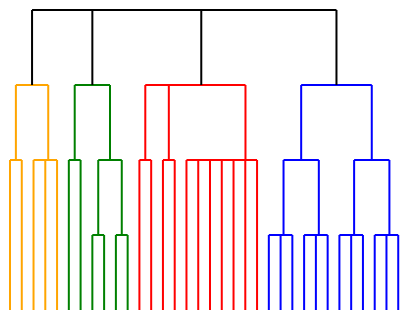

In [11]:
image = visualize_dendrogram(dendrogram)
SVG(image)

In [12]:
# find a clustering with n clusters (at least n , if there is no cut with n clusters)
labels = cut_straight(dendrogram, n_clusters=2)
len(set(labels))

4

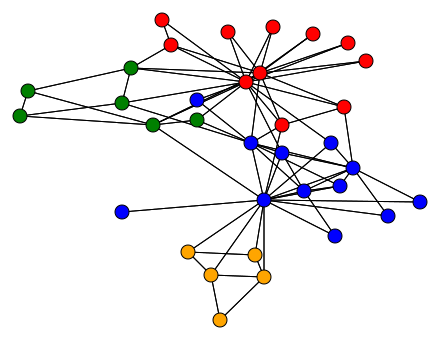

In [13]:
image = visualize_graph(adjacency, position, labels=labels)
SVG(image)

## To do

* Cluster the graph by the Paris algorithm.
* Display the dendrogram.
* Display the graph with the top-2 clusters. Compare this clustering to the ground-truth labels.
* Display the graph with the top-4 clusters. Compare this clustering with that given by Louvain (depth 1).
* Display the corresponding aggregate dendrogram (check the parameters of the function ``cut_straight``).

#### **Answers**

- There are two different nodes between the ground truth and the clustering executed by the Paris algorithm.

- The graph with the top-4 clusters also differs in 2 nodes from the clustering given by Louvain (depth 1). This happens because while Louvain tries to increase modularity, Paris is searching for the strongest links.

In [14]:
#### Cluster the graph by the Paris algorithm
paris = Paris()
dendrogram = paris.fit_predict(adjacency)

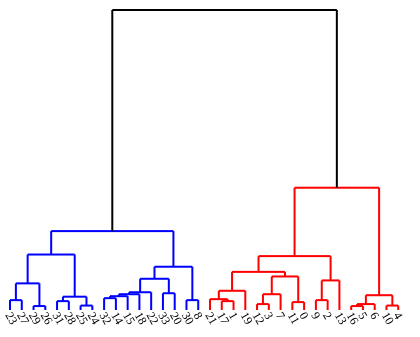

In [15]:
##### Display the dendrogram
image = visualize_dendrogram(dendrogram, names=np.arange(34))
SVG(image)

In [16]:
#### Display the graph with the top2 clusters
labels = cut_straight(dendrogram, n_clusters=2)
len(set(labels))

2

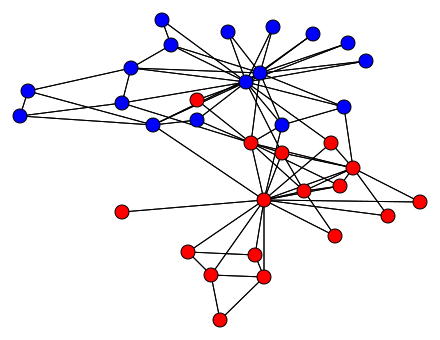

In [17]:
image = visualize_graph(adjacency, position, labels=labels)
SVG(image)

In [18]:
#### Display the graph with the top4 clusters
labels, dendrogram = cut_straight(dendrogram, n_clusters=4, return_dendrogram=True)
len(set(labels))

4

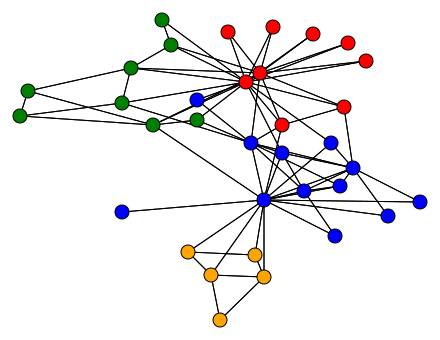

In [19]:
image = visualize_graph(adjacency, position, labels=labels)
SVG(image)

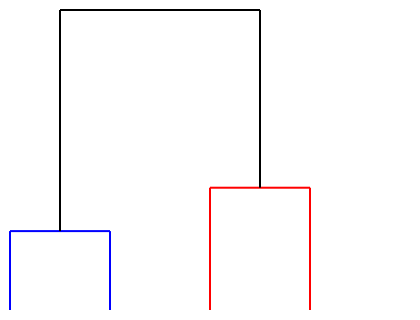

In [20]:
#### Display the corresponding aggregated dendrogam
image = visualize_dendrogram(dendrogram)
SVG(image)

## Openflights


In [44]:
dataset = openflights

In [45]:
adjacency = dataset.adjacency
position = dataset.position
names = dataset.names

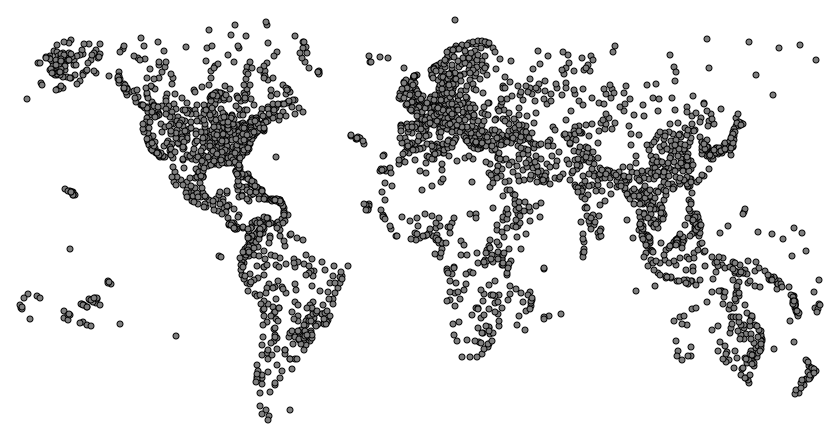

In [42]:
image = visualize_graph(adjacency, position, width=800, height=400, node_size=3, display_edges=False)
SVG(image)

## To do

* Display the same world map with the top-10 clusters found by Paris.<br>
Refer to the [tutorial on Louvain](https://scikit-network.readthedocs.io/en/latest/tutorials/clustering/louvain.html) to display the aggregate graph.
* Display the aggregate dendrogram formed by the top-40 clusters found by Paris, with the name of the top airport  (in traffic) of each cluster. <br>Check the parameters of the function ``visualize_dendrogram`` for better visualization.

In [46]:
#### Display the same world map with the top-10 clsuters found by Paris
paris = Paris()
dendrogram = paris.fit_predict(adjacency)
labels = cut_straight(dendrogram, n_clusters=12)
len(set(labels))

12

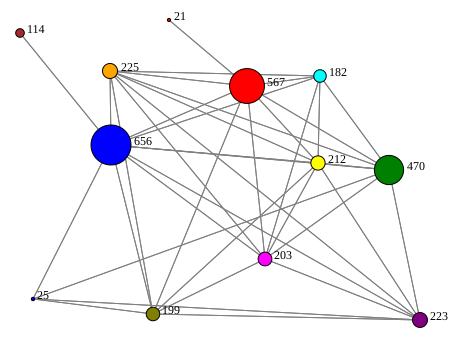

In [47]:
adjacency_aggregate = aggregate_graph(adjacency, labels)

average = normalize(get_membership(labels).T)
position_aggregate = average.dot(position)

labels_unique, counts = np.unique(labels, return_counts=True)

image = visualize_graph(adjacency_aggregate, position_aggregate, counts, labels=labels_unique,
                  display_node_weight=True, node_weights=counts)
SVG(image)

In [26]:
print(len(labels))

3097


In [27]:
#### Display the aggreagated dendrogram formed by the top-40 clusters found by Paris with the name of the top airport (in traffic) of each cluster

  # retrieve top-40 dendrogram found by Paris
labels, dendrogram_40 = cut_straight(dendrogram, n_clusters=40, return_dendrogram=True)

n_clusters = labels.max() + 1
  # name of the top airport (in traffic) of each cluster
top_airport_per_cluster = np.full(n_clusters, -1)
max_traffic_per_cluster = np.zeros(n_clusters)

traffic_per_airport = np.asarray(np.sum(adjacency, axis=0) + np.sum(adjacency, axis=1).T).ravel()

  # max traffic per cluster
unique_labels = np.unique(labels)
for c in unique_labels:
  cluster_nodes = np.where(labels == c)[0]
  cluster_traffic = traffic_per_airport[cluster_nodes]
  best_node = cluster_nodes[np.argmax(cluster_traffic)]
  top_airport_per_cluster[c] = best_node
  max_traffic_per_cluster[c] = np.max(cluster_traffic)

for (traffic, name) in zip(max_traffic_per_cluster, top_airport_per_cluster):
  print(traffic, names[name])

764.0 Hartsfield Jackson Atlanta International Airport
668.0 Dallas Fort Worth International Airport
278.0 Sydney Kingsford Smith International Airport
554.0 Domodedovo International Airport
664.0 Beijing Capital International Airport
528.0 Dubai International Airport
524.0 Lester B. Pearson International Airport
424.0 Miami International Airport
360.0 Guarulhos - Governador André Franco Montoro International Airport
422.0 Incheon International Airport
496.0 OR Tambo International Airport
352.0 Kuala Lumpur International Airport
826.0 Charles de Gaulle International Airport
104.0 Ted Stevens Anchorage International Airport
188.0 Jorge Chávez International Airport
816.0 Dublin Airport
354.0 Birmingham International Airport
360.0 Suvarnabhumi Airport
268.0 Calgary International Airport
422.0 Paris-Orly Airport
752.0 London Gatwick Airport
558.0 Oslo Gardermoen Airport
602.0 Barcelona International Airport
546.0 Adolfo Suárez Madrid–Barajas Airport
118.0 Mehrabad International Airport
708

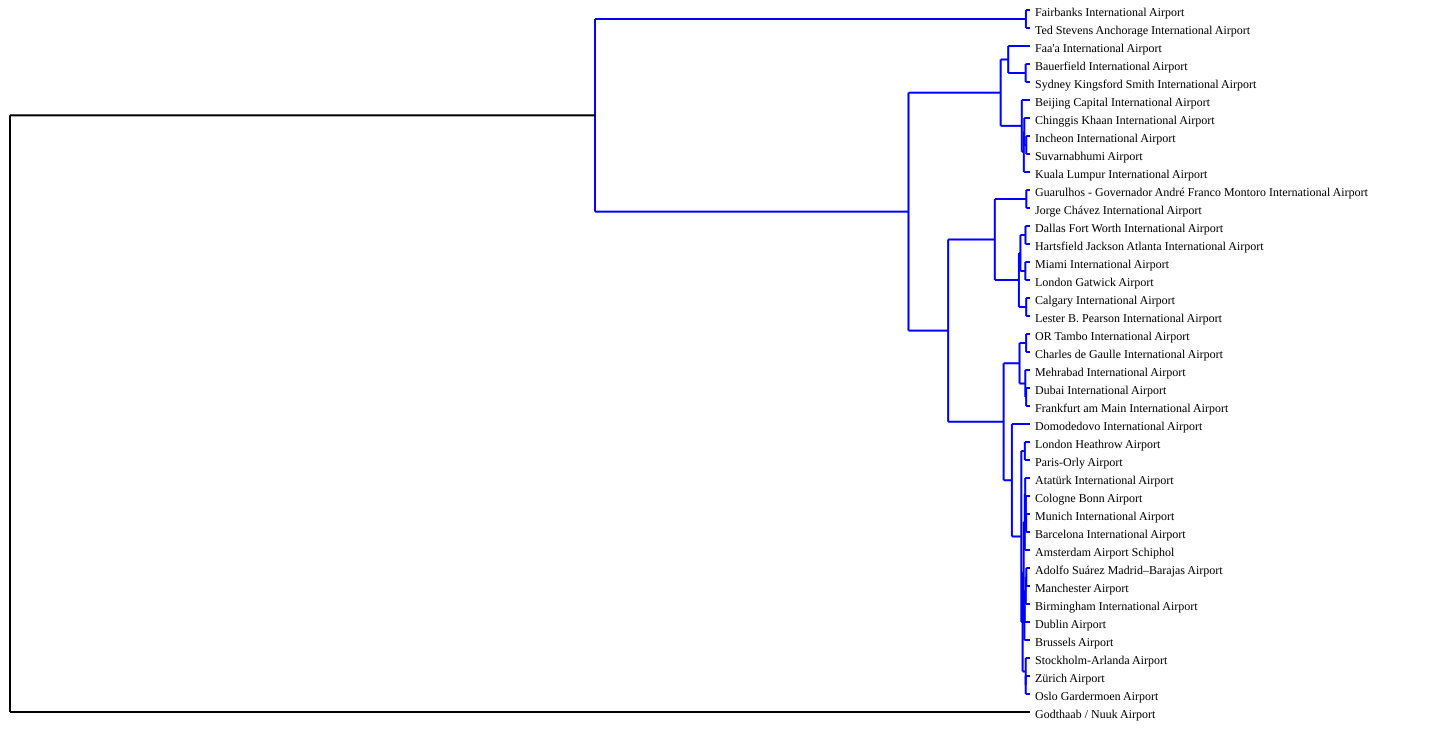

In [28]:
image = visualize_dendrogram(
    dendrogram_40,
    names=names[top_airport_per_cluster],
    height=600,
    width=850,
    scale=1.2,
    rotate=True,
)

SVG(image)

## 2. Directed graphs

## Wikipedia Vitals

In [29]:
dataset = wikivitals

In [30]:
adjacency = dataset.adjacency
names = dataset.names

## To do

* Cluster the graph by the Paris algorithm.
* Give the size and top-5 articles (in terms of Personalized PageRank) of each of the top-40 clusters found by Paris.
* Display the aggregate dendrogram formed by the top-40 clusters, with the name of the top article of each cluster. Comment the results.


##### **Answers**

- The name of each cluster is given by a topic that summarize or are really relevant to a certain field, connecting to several other pages. In this case, after executing Paris and then PageRank, we know that both the degrees of the node itself and of its connections are relevant factors to determine the scores.

In [31]:
#### Cluster the graph by the Paris algorithm
paris = Paris()
dendrogram = paris.fit_predict(adjacency)

In [32]:
#### Size and top-5 articles (in terms of Personalized PageRank) of each of the top40 clusters found by Paris

  # top40 clusters by Paris
labels, dendrogram_40 = cut_straight(dendrogram, n_clusters=40, return_dendrogram=True)

In [33]:
  # personalized pagerank
pagerank = PageRank()

top5_pages = {}

for k in np.unique(labels):
    cluster_nodes = np.where(labels == k)[0]

    if len(cluster_nodes) == 0:
        continue

    weights = np.zeros(adjacency.shape[0])
    weights[cluster_nodes] = 1 / len(cluster_nodes)

    scores = pagerank.fit_predict(adjacency, weights=weights)

    top_nodes = cluster_nodes[np.argsort(-scores[cluster_nodes])[:5]]

    top5_pages[k] = top_nodes

    print(f"Cluster {k} | size {len(cluster_nodes)}")
    for node in top_nodes:
        print(" ", names[node])
    print()


Cluster 0 | size 726
  The New York Times
  BBC
  Time (magazine)
  Encyclopædia Britannica
  Jazz

Cluster 1 | size 674
  Taxonomy (biology)
  Animal
  Chordate
  Permian
  Jurassic

Cluster 2 | size 604
  Plant
  Flowering plant
  Protein
  Sugar
  Gloss (optics)

Cluster 3 | size 478
  World Health Organization
  Medical diagnosis
  Bacteria
  Cancer
  Immune system

Cluster 4 | size 427
  Water
  Pressure
  Plate tectonics
  Glacier
  Erosion

Cluster 5 | size 329
  Albert Einstein
  Physics
  International System of Units
  Electron
  Kelvin

Cluster 6 | size 318
  Christianity
  Catholic Church
  Eastern Orthodox Church
  Judaism
  Augustine of Hippo

Cluster 7 | size 317
  Oxygen
  Hydrogen
  Carbon
  Nitrogen
  Iron

Cluster 8 | size 293
  Immanuel Kant
  David Hume
  Epistemology
  Age of Enlightenment
  Logic

Cluster 9 | size 289
  Egypt
  Islam
  Iran
  Persian language
  Syria

Cluster 10 | size 287
  Karl Marx
  United Nations
  Adam Smith
  John Stuart Mill
  Economics



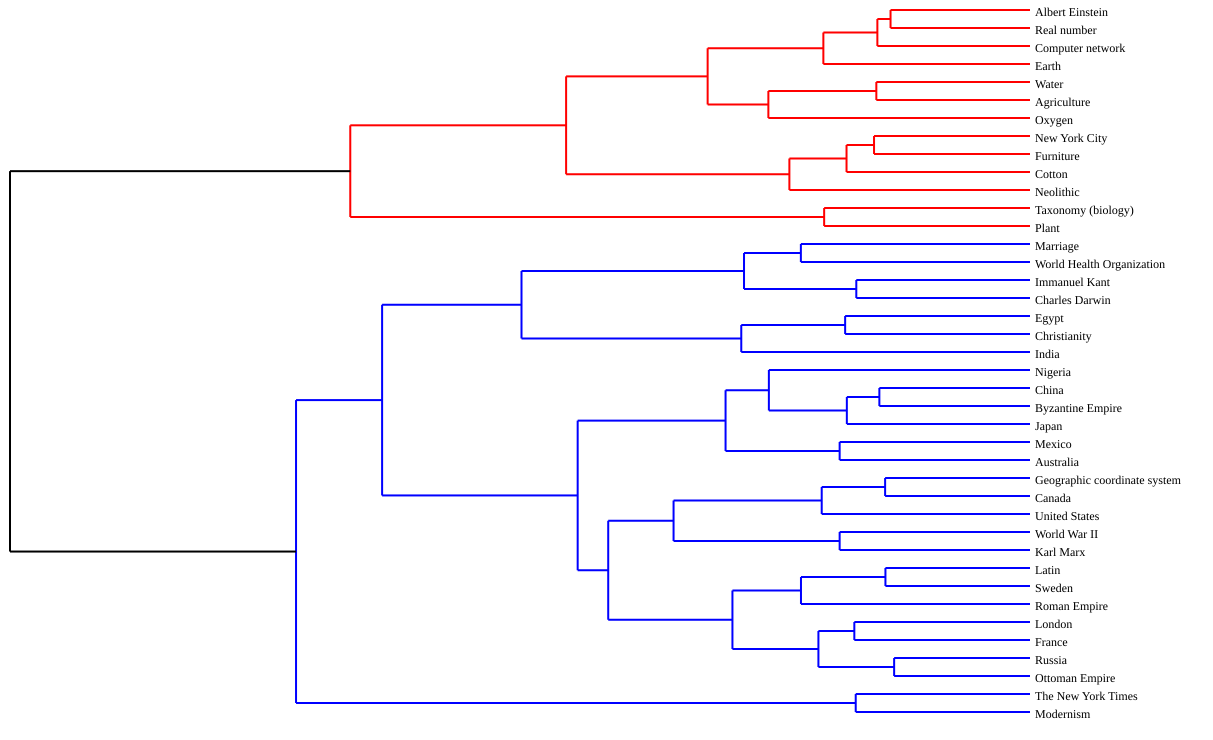

In [34]:
##### Display the aggregate dendrogram formed by the top-40 clusters, with the name of the top article of each cluster.

  # top page per cluster
top_page_per_cluster = [tops[0] for tops in top5_pages.values()]


image = visualize_dendrogram(
    dendrogram_40,
    names=names[top_page_per_cluster],
    height=600,
    width=850,
    scale=1.2,
    rotate=True,
)

SVG(image)

## To do

* Complete the following function that returns the nested clusters from a target node in a dendrogram.
* Give the size and top-5 articles of each nested cluster from the article **Riverboat**.
* Do the same with another article of your choice.

In [35]:
def get_nested_clusters(dendrogram: np.ndarray, node: int):
    '''Get the nested clusters of a node, following the path from the corresponding leaf to the root in the dendrogram.

    Parameters
    ----------
    dendrogram:
        Dendrogram
    node:
        Target node

    Returns
    -------
    cluster_nested: list of list
        Nested clusters, as a partition of the set of nodes
        (the k-th nested cluster is the concatenation of the first k lists).

    Example
    -------
    >>> dendrogram = np.array([[0, 1, 1, 2], [2, 3, 1, 2], [4, 5, 1, 4]])
    >>> get_nested_clusters(dendrogram, 0)
    [[0], [1], [2, 3]]
    '''
    n = dendrogram.shape[0] + 1

    cluster = {i: [i] for i in range(n)}
    nested_clusters = [[node]]
    cluster_index = node

    for t in range(n - 1):
        i = int(dendrogram[t][0])
        j = int(dendrogram[t][1])
        # to be completed
        candidate_cluster_idx = t + n
        cluster[candidate_cluster_idx] = cluster[i] + cluster[j]

        if (cluster_index == i):
          nested_clusters.append(cluster[j])
          cluster_index = candidate_cluster_idx

        elif (cluster_index == j):
          nested_clusters.append(cluster[i])
          cluster_index = candidate_cluster_idx


    return nested_clusters

In [36]:
  # retrieve Riverboat's node index
riverboat_node = int(np.where(names == "Riverboat")[0][0])

  # retrieve Riverboat's nested clusters
nested_clusters = get_nested_clusters(dendrogram, riverboat_node)

  # labels of nodes
labels = -np.ones(len(names), dtype=int)

for k, cluster in enumerate(nested_clusters):
    for node in cluster:
        labels[node] = k

In [37]:
  # Size and top5 articles of each nested cluster from riverboat
pagerank = PageRank()

top5_pages = {}

for k in np.unique(labels):
    cluster_nodes = np.where(labels == k)[0]

    if len(cluster_nodes) == 0:
        continue

    weights = np.zeros(adjacency.shape[0])
    weights[cluster_nodes] = 1 / len(cluster_nodes)

    scores = pagerank.fit_predict(adjacency, weights=weights)

    top_nodes = cluster_nodes[np.argsort(-scores[cluster_nodes])[:5]]

    top5_pages[k] = top_nodes

    print(f"Cluster {k} | size {len(cluster_nodes)}")
    for node in top_nodes:
        print(" ", names[node])
    print()


Cluster 0 | size 1
  Riverboat

Cluster 1 | size 1
  Tanker (ship)

Cluster 2 | size 2
  Merchant ship
  Passenger ship

Cluster 3 | size 1
  Freight transport

Cluster 4 | size 1
  Cargo ship

Cluster 5 | size 1
  Fishing vessel

Cluster 6 | size 1
  Barge

Cluster 7 | size 1
  Ferry

Cluster 8 | size 1
  Ship

Cluster 9 | size 1
  Cargo

Cluster 10 | size 1
  Shipbuilding

Cluster 11 | size 5
  Pier
  Dock (maritime)
  Harbor
  Watermill
  Diospyros

Cluster 12 | size 27
  Rapid transit
  Airport
  Rail transport
  Airline
  High-speed rail

Cluster 13 | size 85
  Internal combustion engine
  Diesel engine
  Aircraft
  Jet engine
  Torque

Cluster 14 | size 41
  New York City
  Urban planning
  Suburb
  City
  Central Park

Cluster 15 | size 91
  Furniture
  Column
  Dome
  Arch
  Bedroom

Cluster 16 | size 205
  Cotton
  Jewellery
  Textile
  Silk
  Polyester

Cluster 17 | size 89
  Neolithic
  Cremation
  Behavioral modernity
  Control of fire by early humans
  Reservoir

Cluster 1

In [38]:
##### Repeat the exercise from the node Brazil

  # retrieve Brazil node index
brazil_node = int(np.where(names == "Brazil")[0][0])

  # retrieve Brazil nested clusters
nested_clusters = get_nested_clusters(dendrogram, brazil_node)

  # labels of nodes
labels = -np.ones(len(names), dtype=int)

for k, cluster in enumerate(nested_clusters):
    for node in cluster:
        labels[node] = k

In [39]:
  # Size and top5 articles of each nested cluster from Brazil
pagerank = PageRank()

top5_pages = {}

for k in np.unique(labels):
    cluster_nodes = np.where(labels == k)[0]

    if len(cluster_nodes) == 0:
        continue

    weights = np.zeros(adjacency.shape[0])
    weights[cluster_nodes] = 1 / len(cluster_nodes)

    scores = pagerank.fit_predict(adjacency, weights=weights)

    top_nodes = cluster_nodes[np.argsort(-scores[cluster_nodes])[:5]]

    top5_pages[k] = top_nodes

    print(f"Cluster {k} | size {len(cluster_nodes)}")
    for node in top_nodes:
        print(" ", names[node])
    print()


Cluster 0 | size 1
  Brazil

Cluster 1 | size 5
  Tropical climate
  Tropics
  Eugenius Warming
  Melastomataceae
  Cerrado

Cluster 2 | size 18
  Rainforest
  Biome
  Savanna
  Steppe
  Tarzan

Cluster 3 | size 1
  Europe

Cluster 4 | size 179
  Pacific Ocean
  Arctic Ocean
  Southern Ocean
  Indian Ocean
  Gulf of Mexico

Cluster 5 | size 55
  Australia
  Malaysia
  Papua New Guinea
  Tuvalu
  Cook Islands

Cluster 6 | size 225
  Mexico
  Spanish language
  Argentina
  Colombia
  Köppen climate classification

Cluster 7 | size 753
  China
  Japan
  Chinese language
  Indonesia
  Thailand

Cluster 8 | size 2066
  United States
  World War II
  France
  Geographic coordinate system
  United Kingdom

Cluster 9 | size 1949
  India
  Christianity
  Islam
  Egypt
  Buddhism

Cluster 10 | size 975
  The New York Times
  BBC
  Time (magazine)
  Encyclopædia Britannica
  The Washington Post

Cluster 11 | size 3784
  Taxonomy (biology)
  Animal
  Oxygen
  Earth
  Hydrogen

